# Portfolio recommendation (long-only, factor model)

One call to `stonks.optimize_portfolio`: fetch the last `MONTHS` months of the `TOP_N` most-liquid stocks, build a factor-model covariance (rank-`K` SVD + idiosyncratic diagonal), and solve the long-only mean-variance problem $\max\ \mu^\top w - \tfrac{\gamma}{2}w^\top\Sigma w$ with $w=\mathrm{softmax}(z)$. Returns the recommended holdings and weights.

> In-sample estimate — validate out-of-sample (see `portfolio_oos_test`). Not financial advice.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stonks import optimize_portfolio

%matplotlib inline


## Parameters


In [2]:
TOP_N = 500
MONTHS = 3
GAMMA = 50.0      # risk aversion (higher = more diversified)
K = 25            # SVD factors; also the concentration dial
N_RESTARTS = 30   # random inits; best final objective wins
LR = 0.05         # learning rate (0.5 made some restarts overshoot and drop)
INTERVAL = "1d"


## Recommended portfolio

The softmax mean-variance problem is **non-convex in $z$** — different random inits land in different local optima (this is why re-running the old notebook gave different answers every time). So we run `N_RESTARTS` random inits and keep the restart with the **highest final objective** (we're doing gradient ascent).

In [3]:
weights, histories = optimize_portfolio(
    top_n=TOP_N, months=MONTHS, interval=INTERVAL,
    gamma=GAMMA, K=K, n_restarts=N_RESTARTS, lr=LR, return_history=True,
)
finals = [h[-1] for h in histories]
best = int(np.argmax(finals))
print(f"{N_RESTARTS} restarts; best = restart {best} (final objective {finals[best]:.3e})")
print(f"{len(weights)} holdings, sum(weight)={weights['weight'].sum():.4f}")
weights

30 restarts; best = restart 10 (final objective 2.799e-03)
45 holdings, sum(weight)=1.0000


,weight
ticker,
CWST,0.068936
SPSC,0.064577
DXCM,0.064543
BKD,0.058864
BRKR,0.053167
OPCH,0.041233
APA,0.039988
PTEN,0.035145
ALL,0.032492


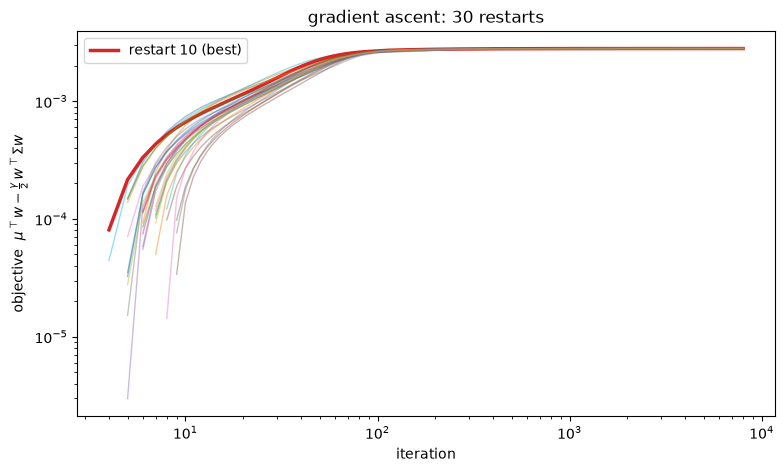

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, h in enumerate(histories):
    x = np.arange(1, len(h) + 1)
    pos = h > 0                            # hide the (possibly negative) early transient
    ax.plot(x[pos], h[pos], lw=2.5 if i == best else 1.0,
            alpha=1.0 if i == best else 0.45,
            color="tab:red" if i == best else None,
            label=f"restart {best} (best)" if i == best else None)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel(r"objective  $\mu^\top w-\frac{\gamma}{2}\,w^\top\Sigma w$")
ax.set_title(f"gradient ascent: {len(histories)} restarts")
ax.legend()

In [5]:
h

array([-0.00100735, -0.00076476, -0.0005483 , ...,  0.00279897,
        0.00279897,  0.00279897], shape=(8000,))

Text(0.5, 1.0, 'Long-only weights ($\\gamma$=50.0, K=25)')

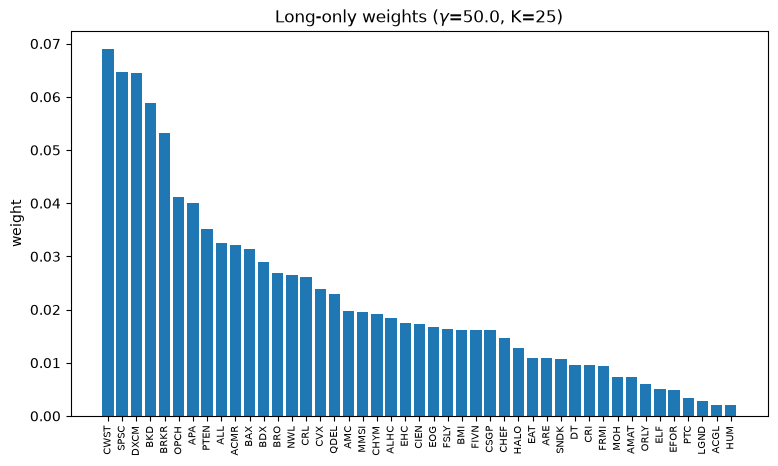

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(weights)), weights["weight"])
ax.set_xticks(range(len(weights))); ax.set_xticklabels(weights.index, rotation=90, fontsize=7)
ax.set_ylabel("weight"); ax.set_title(rf"Long-only weights ($\gamma$={GAMMA}, K={K})")


In [7]:
print(f"{'gamma':>6} {'holdings':>9}")
for g in [2, 5, 10, 20, 50, 100]:
    w = optimize_portfolio(top_n=TOP_N, months=MONTHS, interval=INTERVAL,
                           gamma=g, K=K, n_restarts=3, lr=LR)
    print(f"{g:6g} {len(w):9d}")

 gamma  holdings
     2         7
     5         8
    10        11
    20        18
    50        45
   100        80


## Knobs

- **$\gamma$** — risk aversion. Higher → more diversified, lower vol.
- **$K$** — number of SVD factors, and the concentration dial: larger $K$ shrinks the idiosyncratic $\Psi$ → fewer, more concentrated holdings (too large reabsorbs Marchenko-Pastur noise).
- **months / top_n** — window length and universe size.
- **lr** — learning rate. Too large (0.5) and some restarts overshoot — their curves drop from the peak; 0.05 ascends smoothly to the same optimum.
- **n_restarts** — random inits; the best final objective wins (the problem is non-convex, so a single init is an arbitrary local optimum).

Same thing from the command line:

```
stonks portfolio --top-n 500 --months 3 --gamma 50 -k 25 --n-restarts 10
```